In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Step - 01 : Data Loading


In [18]:
# Set random seed for reproducibility.

np.random.seed(42)
n_samples = 5000

# age normal distributions

age = np.random.normal(40, 15, n_samples).clip(18, 80).astype(int)

# Gender: 0 = Female, 1 = Male
gender = np.random.choice([0, 1], n_samples, p=[0.5, 0.5])

# Height: normal distribution, clip to 1.4-2.0 m
height = np.random.normal(1.7, 0.1, n_samples).clip(1.4, 2.0)


# Define target categories (0: Normal, 1: Overweight, 2: Obese Type I, 3: Obese Type II, 4: Obese Type III)

In [19]:
target_probs = [0.3, 0.25, 0.2, 0.15, 0.1]
target = np.random.choice([0,1,2,3,4], n_samples, p=target_probs)


# Map target to approximate BMI ranges

In [20]:
bmi_ranges = {
    0: (18.5, 25.0),
    1: (25.0, 30.0),
    2: (30.0, 35.0),
    3: (35.0, 40.0),
    4: (40.0, 50.0)

}
bmi = np.zeros(n_samples)
for i in range(n_samples):
    low, high = bmi_ranges[target[i]]
    # Add a bit of noise to make it realistic
    bmi[i] = np.random.uniform(low, high) + np.random.normal(0, 0.5)
    # Clip to avoid extreme values
    bmi[i] = np.clip(bmi[i], low, high)
# Compute weight from BMI and height
weight = bmi * (height ** 2)

# Family History of Obesity: more likely if target > 0
family_history = np.zeros(n_samples)
for i in range(n_samples):
    if target[i] == 0:
        family_history[i] = np.random.choice([0,1], p=[0.7, 0.3])
    else:
        family_history[i] = np.random.choice([0,1], p=[0.3, 0.7])
# Physical Activity Frequency (hours/week): inversely related to obesity
# Base hours: higher for normal weight, lower for obese
base_hours = {0: 5, 1: 4, 2: 3, 3: 2, 4: 1}
activity_hours = np.array([base_hours[t] + np.random.normal(0, 0.5) for t in target])
activity_hours = activity_hours.clip(0, 12)

In [21]:
# Dietary Habits
diet_options = ['Balanced', 'High-calorie', 'Low-calorie']

# Normal weight often balanced or low-calorie; obese often high-calorie
diet = []
for t in target:
    if t == 0:
        p = [0.6, 0.1, 0.3]
    elif t == 1:
        p = [0.5, 0.2, 0.3]
    elif t == 2:
        p = [0.4, 0.4, 0.2]
    elif t == 3:
        p = [0.3, 0.6, 0.1]
    else:
        p = [0.2, 0.7, 0.1]
    diet.append(np.random.choice(diet_options, p=p))

In [22]:
# Water Intake (liters/day): normally distributed, maybe higher for higher BMI?
water_intake = np.random.normal(2, 0.5, n_samples).clip(0.5, 5.0)


In [23]:
# Smoking Habits: binary, weakly related to obesity
smoking = np.random.choice([0,1], n_samples, p=[0.8, 0.2])

In [24]:
# Alcohol Consumption
alcohol_options = ['Never', 'Occasionally', 'Frequently']
# Normal weight might drink moderately, but no strong trend
alcohol = np.random.choice(alcohol_options, n_samples, p=[0.3, 0.5, 0.2])

In [25]:
# Create DataFrame
data = pd.DataFrame({
    'Age': age,
    'Gender': gender,
    'Height': height,
    'Weight': weight,
    'Family_History_Obesity': family_history,
    'Physical_Activity_Frequency': activity_hours,
    'Dietary_Habits': diet,
    'Water_Intake': water_intake,
    'Smoking_Habits': smoking,
    'Alcohol_Consumption': alcohol,
    'Obesity_Level': target
})

In [26]:
# Map target to labels for readability
obesity_labels = {0: 'Normal Weight', 1: 'Overweight', 2: 'Obese Type I', 3: 'Obese Type II', 4: 'Obese Type III'}
data['Obesity_Level_Label'] = data['Obesity_Level'].map(obesity_labels)

data.head()


,Age,Gender,Height,Weight,Family_History_Obesity,Physical_Activity_Frequency,Dietary_Habits,Water_Intake,Smoking_Habits,Alcohol_Consumption,Obesity_Level,Obesity_Level_Label
0,47,0,1.606153,79.745217,1.0,2.983020,Balanced,2.100478,1,Never,2,Obese Type I
1,37,0,1.645359,84.789160,1.0,3.408422,Balanced,2.025654,0,Never,2,Obese Type I
2,49,0,1.671776,93.866441,1.0,3.619451,High-calorie,2.278710,0,Occasionally,2,Obese Type I
3,62,0,1.805077,64.082561,0.0,3.817428,Low-calorie,0.769555,0,Occasionally,0,Normal Weight
4,36,0,1.583706,84.979359,1.0,2.631666,Balanced,2.225132,0,Never,2,Obese Type I


# step - 02 : Data Overview

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data.info()
data.describe()
print("Missing values:\n", data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          5000 non-null   int64  
 1   Gender                       5000 non-null   int64  
 2   Height                       5000 non-null   float64
 3   Weight                       5000 non-null   float64
 4   Family_History_Obesity       5000 non-null   float64
 5   Physical_Activity_Frequency  5000 non-null   float64
 6   Dietary_Habits               5000 non-null   object 
 7   Water_Intake                 5000 non-null   float64
 8   Smoking_Habits               5000 non-null   int64  
 9   Alcohol_Consumption          5000 non-null   object 
 10  Obesity_Level                5000 non-null   int64  
 11  Obesity_Level_Label          5000 non-null   object 
dtypes: float64(5), int64(4), object(3)
memory usage: 468.9+ KB
Missing values:
 

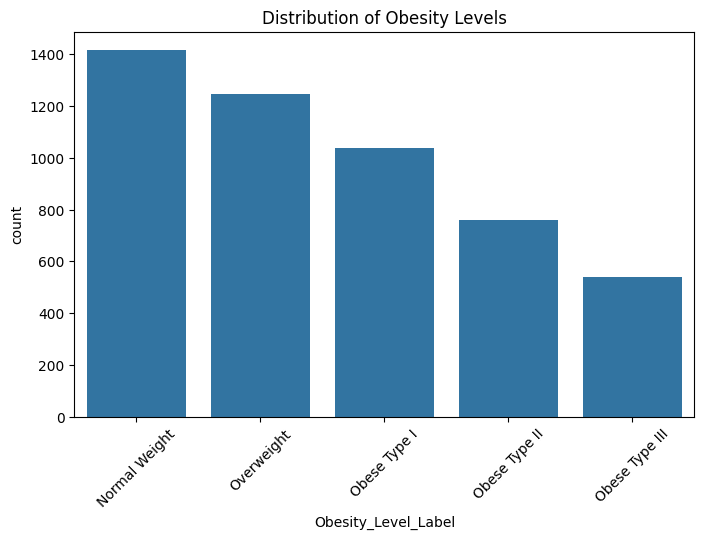

In [31]:
# Distribution of target
plt.figure(figsize=(8,5))
sns.countplot(x='Obesity_Level_Label', data=data, order=obesity_labels.values())
plt.title('Distribution of Obesity Levels')
plt.xticks(rotation=45)
plt.show()

# Ste - 03 : EDA

## Numerical Features vs Target

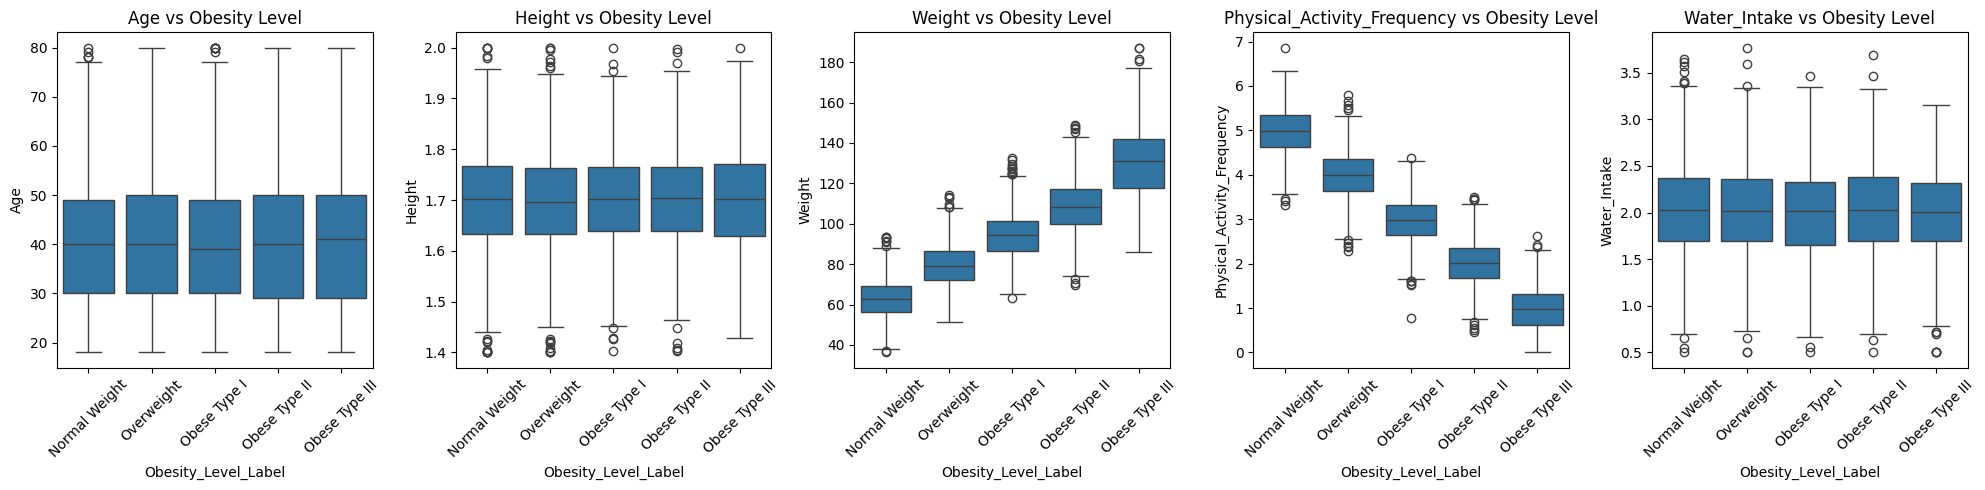

In [32]:
# Boxplots for numerical features by target
num_features = ['Age', 'Height', 'Weight', 'Physical_Activity_Frequency', 'Water_Intake']
fig, axes = plt.subplots(1, len(num_features), figsize=(20, 5))
for i, col in enumerate(num_features):
    sns.boxplot(x='Obesity_Level_Label', y=col, data=data, ax=axes[i], order=obesity_labels.values())
    axes[i].set_title(f'{col} vs Obesity Level')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Correlation matrix for numerical features

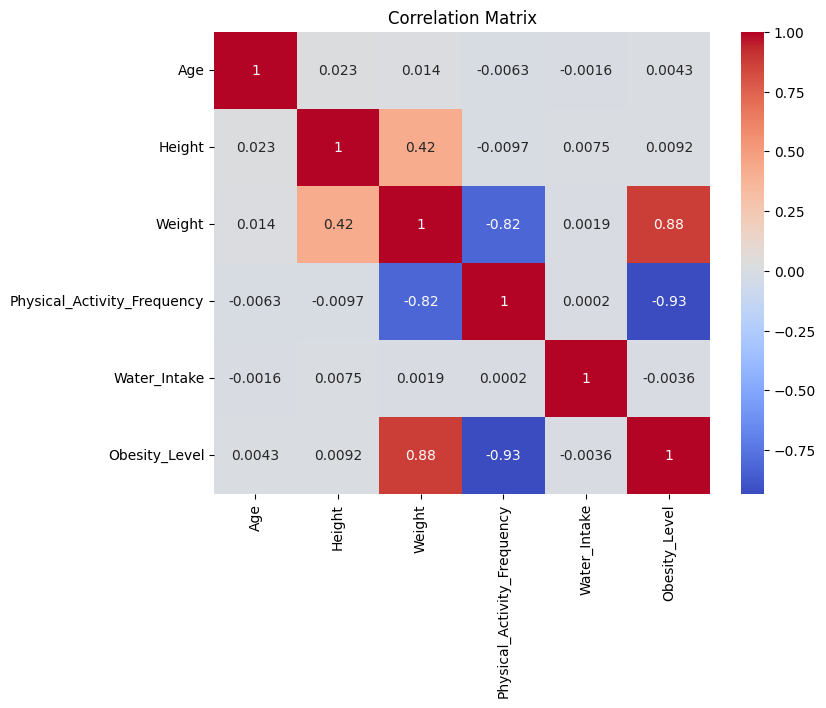

In [33]:

corr = data[num_features + ['Obesity_Level']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Categorical Features vs Target

##  Gender distribution across target

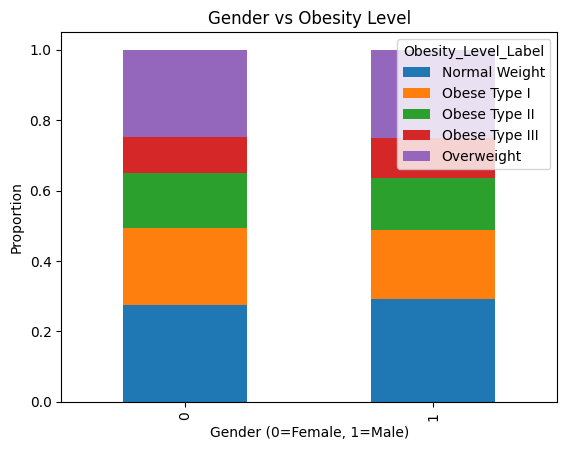

In [34]:

pd.crosstab(data['Gender'], data['Obesity_Level_Label'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Gender vs Obesity Level')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Proportion')
plt.show()

## Family History

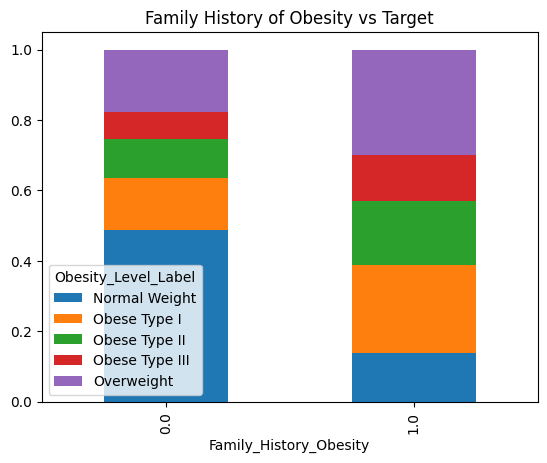

In [35]:

pd.crosstab(data['Family_History_Obesity'], data['Obesity_Level_Label'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Family History of Obesity vs Target')
plt.show()

# Dietary Habits

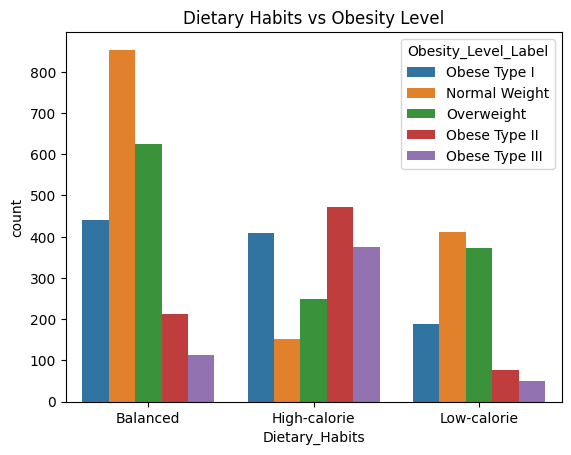

In [36]:

sns.countplot(x='Dietary_Habits', hue='Obesity_Level_Label', data=data, order=['Balanced','High-calorie','Low-calorie'])
plt.title('Dietary Habits vs Obesity Level')
plt.show()

# Alcohol Consumption

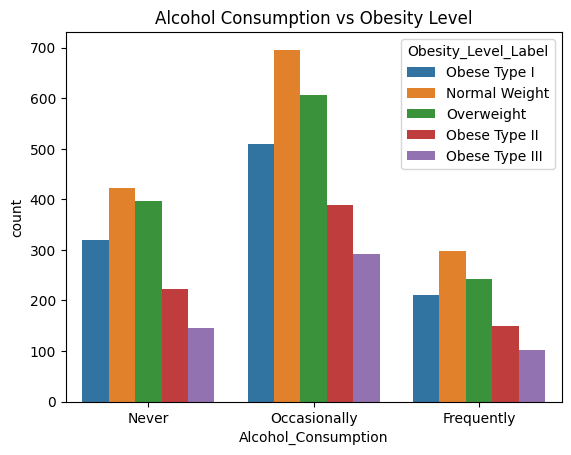

In [37]:

sns.countplot(x='Alcohol_Consumption', hue='Obesity_Level_Label', data=data, order=['Never','Occasionally','Frequently'])
plt.title('Alcohol Consumption vs Obesity Level')
plt.show()

# Pairplot for selected features

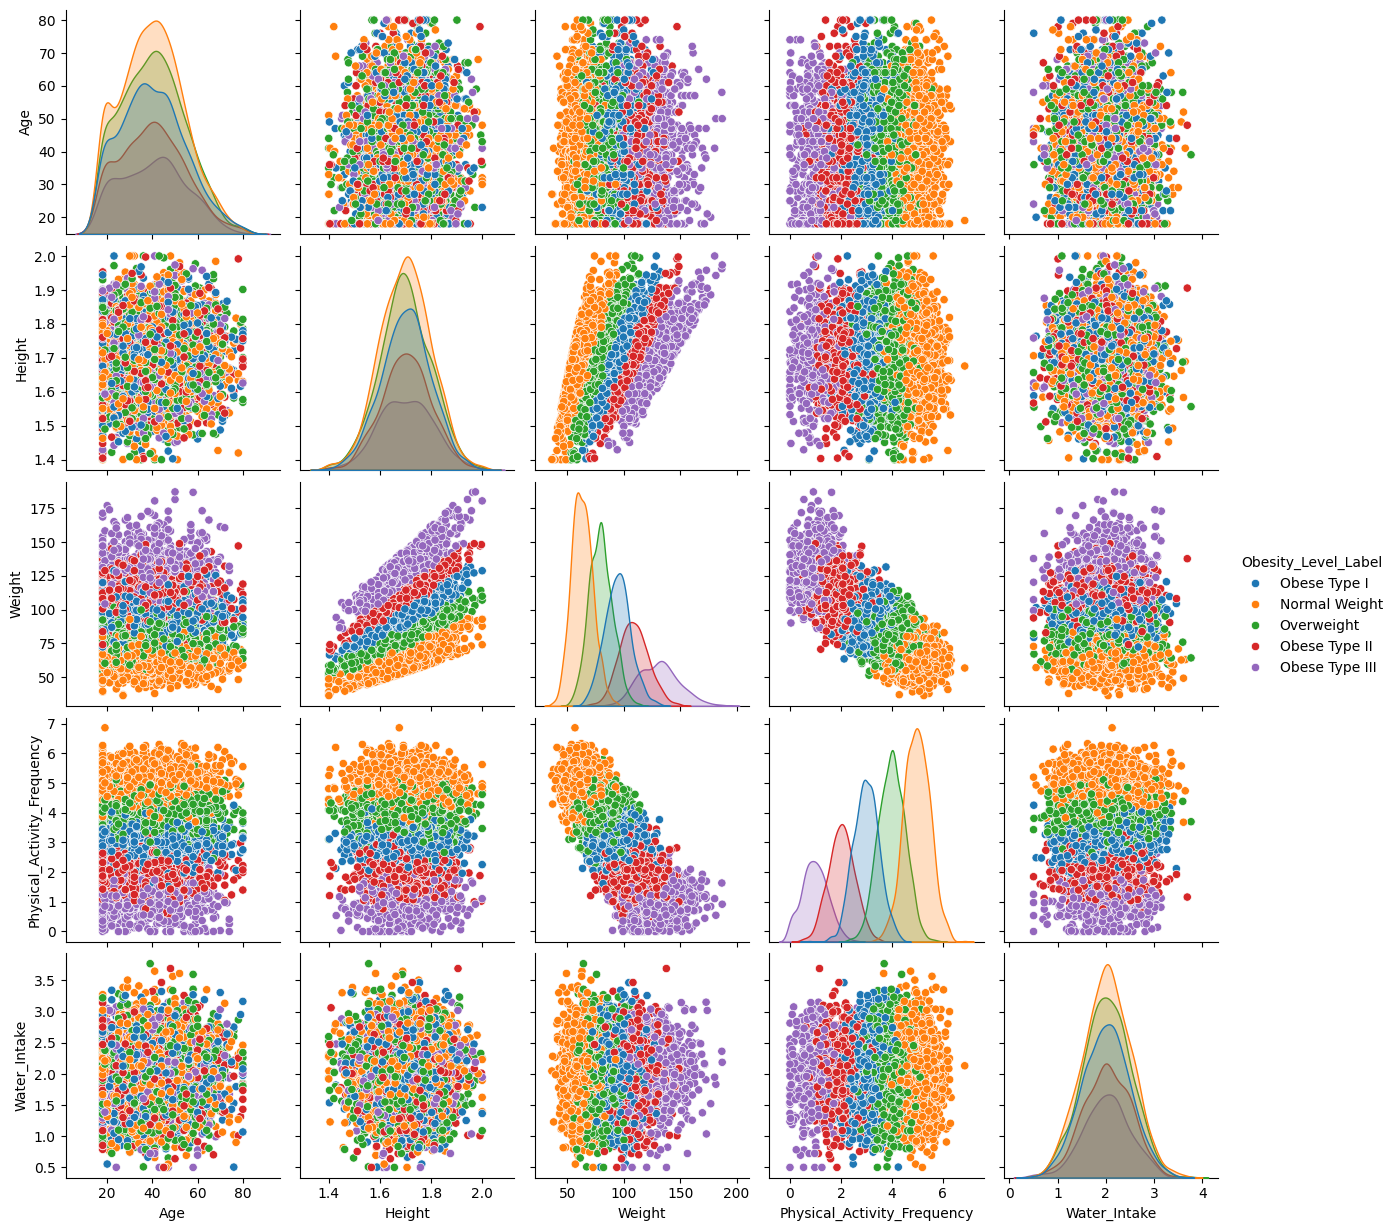

In [38]:
sns.pairplot(data[['Age', 'Height', 'Weight', 'Physical_Activity_Frequency', 'Water_Intake', 'Obesity_Level_Label']], hue='Obesity_Level_Label', diag_kind='kde')
plt.show()

# Preprocessing

## Separate Features and Target

In [39]:
X = data.drop(['Obesity_Level', 'Obesity_Level_Label'], axis=1)
y = data['Obesity_Level']

## Identify Column Types

In [41]:
# Numerical columns
num_cols = ['Age', 'Height', 'Weight', 'Physical_Activity_Frequency', 'Water_Intake']

# Categorical columns (nominal)
cat_cols_nominal = ['Gender', 'Family_History_Obesity', 'Smoking_Habits']
cat_cols_ordinal = ['Dietary_Habits', 'Alcohol_Consumption']

# For ordinal columns, define the order
diet_order = ['Low-calorie', 'Balanced', 'High-calorie']
alcohol_order = ['Never', 'Occasionally', 'Frequently']

# Create Preprocessing Pipelines

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Numerical pipeline: standard scaling
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Nominal pipeline: one-hot encoding
nominal_pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, drop='first'))
])

# Ordinal pipeline: ordinal encoding
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[diet_order, alcohol_order]))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('nom', nominal_pipeline, cat_cols_nominal),
    ('ord', ordinal_pipeline, cat_cols_ordinal)
])

# Split the data

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 4000
Test set size: 1000


# Model Building

# Helper Function for Model Evaluation



In [46]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{model_name} - Test Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=obesity_labels.values()))
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=obesity_labels.values(), yticklabels=obesity_labels.values())
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()
    return model

# Apply Preprocessing to Data

In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [51]:
# Logistic Regression
log_reg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'))
])

# Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
])

#  Evaluate each model

Evaluating Logistic Regression...
Logistic Regression - Test Accuracy: 0.9580

Classification Report:
                precision    recall  f1-score   support

 Normal Weight       0.99      0.98      0.98       283
    Overweight       0.94      0.96      0.95       249
  Obese Type I       0.94      0.95      0.94       208
 Obese Type II       0.93      0.96      0.94       152
Obese Type III       1.00      0.94      0.97       108

      accuracy                           0.96      1000
     macro avg       0.96      0.95      0.96      1000
  weighted avg       0.96      0.96      0.96      1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


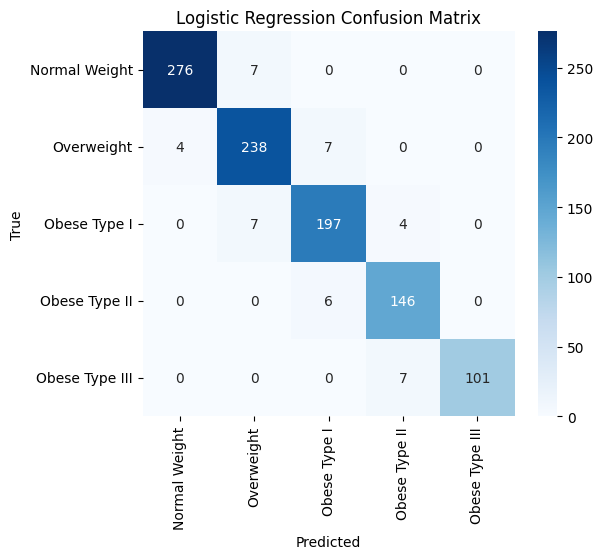

Evaluating Random Forest...
Random Forest - Test Accuracy: 0.9320

Classification Report:
                precision    recall  f1-score   support

 Normal Weight       0.97      0.97      0.97       283
    Overweight       0.93      0.91      0.92       249
  Obese Type I       0.88      0.90      0.89       208
 Obese Type II       0.90      0.91      0.90       152
Obese Type III       0.98      0.96      0.97       108

      accuracy                           0.93      1000
     macro avg       0.93      0.93      0.93      1000
  weighted avg       0.93      0.93      0.93      1000



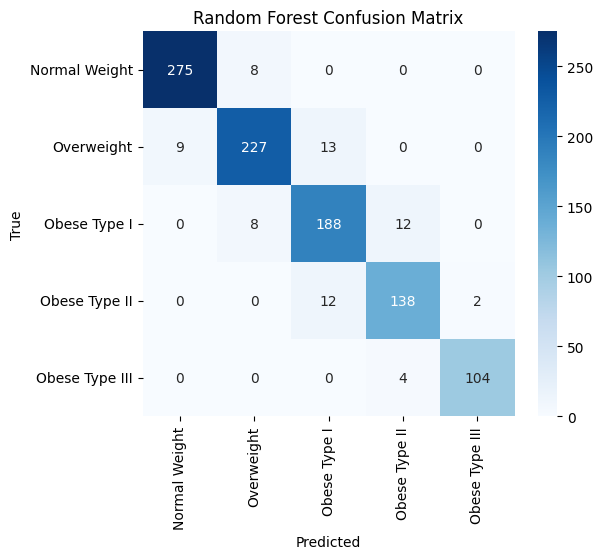

Evaluating XGBoost...
XGBoost - Test Accuracy: 0.9590

Classification Report:
                precision    recall  f1-score   support

 Normal Weight       0.99      0.98      0.99       283
    Overweight       0.96      0.96      0.96       249
  Obese Type I       0.93      0.95      0.94       208
 Obese Type II       0.92      0.95      0.94       152
Obese Type III       0.99      0.94      0.96       108

      accuracy                           0.96      1000
     macro avg       0.96      0.95      0.96      1000
  weighted avg       0.96      0.96      0.96      1000



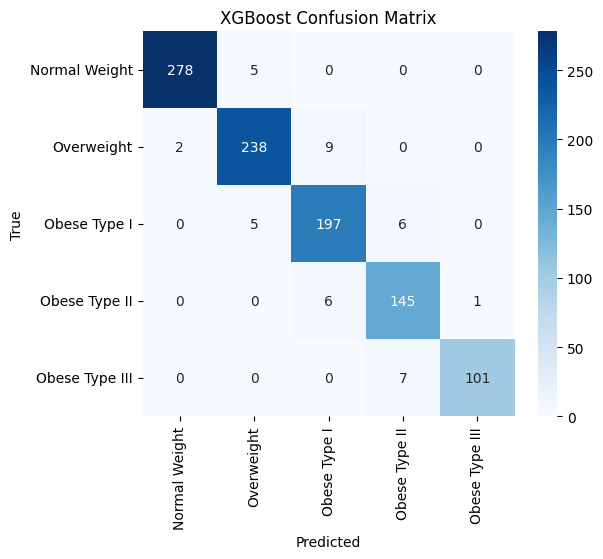

In [54]:

models = {
    'Logistic Regression': log_reg_pipe,
    'Random Forest': rf_pipe,
    'XGBoost': xgb_pipe
}

for name, pipe in models.items():
    print(f"Evaluating {name}...")
    evaluate_model(pipe, X_train, y_train, X_test, y_test, name)

# Hyperparameter Tuning

In [56]:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [57]:
# Random Forest tuning
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf_pipe, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)
print(f"Best parameters for Random Forest: {rf_grid.best_params_}")
print(f"Best cross-validation accuracy: {rf_grid.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters for Random Forest: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best cross-validation accuracy: 0.9155


# # XGBoost tuning

In [58]:

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6, 9],
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb_pipe, param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)
print(f"Best parameters for XGBoost: {xgb_grid.best_params_}")
print(f"Best cross-validation accuracy: {xgb_grid.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters for XGBoost: {'classifier__learning_rate': 0.3, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Best cross-validation accuracy: 0.9570


# Evaluate Best Models on Test Set

=== Best Random Forest on Test Set ===
Best Random Forest - Test Accuracy: 0.9280

Classification Report:
                precision    recall  f1-score   support

 Normal Weight       0.97      0.97      0.97       283
    Overweight       0.92      0.91      0.91       249
  Obese Type I       0.88      0.90      0.89       208
 Obese Type II       0.90      0.91      0.90       152
Obese Type III       0.98      0.95      0.97       108

      accuracy                           0.93      1000
     macro avg       0.93      0.93      0.93      1000
  weighted avg       0.93      0.93      0.93      1000



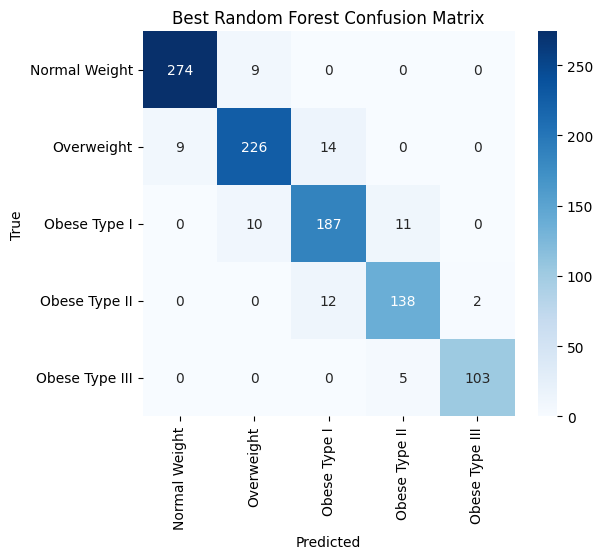

=== Best XGBoost on Test Set ===
Best XGBoost - Test Accuracy: 0.9600

Classification Report:
                precision    recall  f1-score   support

 Normal Weight       0.99      0.98      0.99       283
    Overweight       0.95      0.96      0.96       249
  Obese Type I       0.94      0.95      0.95       208
 Obese Type II       0.93      0.95      0.94       152
Obese Type III       0.98      0.94      0.96       108

      accuracy                           0.96      1000
     macro avg       0.96      0.96      0.96      1000
  weighted avg       0.96      0.96      0.96      1000



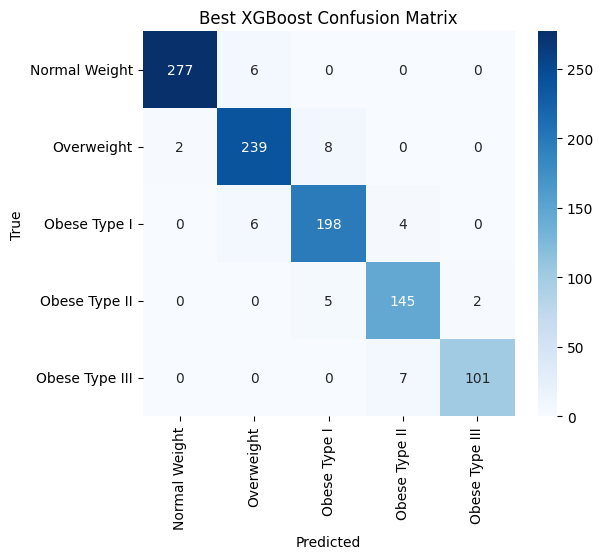

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'Physical_Activity_Frequency',
                                                   'Water_Intake']),
                                                 ('nom',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Gender',
                                                   'Family_History_Obesity',
                                                   'Smoking_Habits']),
                                                 ('ord',
                                                  Pipeline(steps=[...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.3,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [59]:
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

print("=== Best Random Forest on Test Set ===")
evaluate_model(best_rf, X_train, y_train, X_test, y_test, "Best Random Forest")

print("=== Best XGBoost on Test Set ===")
evaluate_model(best_xgb, X_train, y_train, X_test, y_test, "Best XGBoost")

# Feature Importance

In [60]:
# Get feature names after preprocessing
preprocessor_fitted = best_xgb.named_steps['preprocessor']
# Numeric features
num_feats = num_cols
# Nominal features (one-hot encoded)
nominal_encoder = preprocessor_fitted.named_transformers_['nom'].named_steps['onehot']
nominal_feats = nominal_encoder.get_feature_names_out(cat_cols_nominal)
# Ordinal features (single column each)
ordinal_feats = cat_cols_ordinal

all_feats = num_feats + list(nominal_feats) + ordinal_feats

# Get feature importances from XGBoost

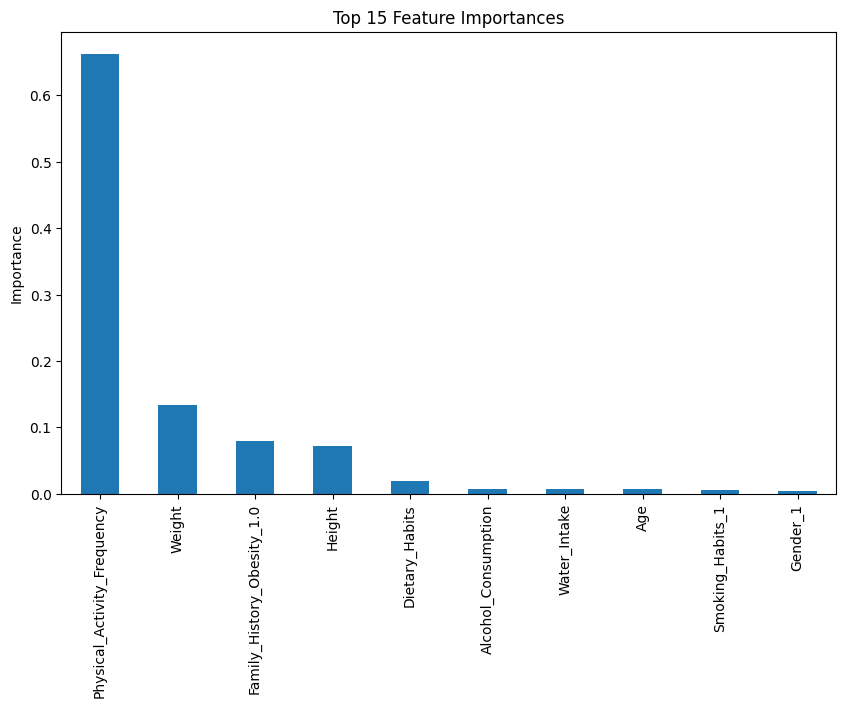

In [61]:

importances = best_xgb.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_feats).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances')
plt.ylabel('Importance')
plt.show()

# Save Model and Preprocessing Components

In [63]:
import joblib
import warnings

In [68]:
import pickle # Import the pickle module
import joblib
import warnings

pickel_model_path = "model.pkl"
with open(pickel_model_path, 'wb') as file:
    pickle.dump(best_xgb, file)